In [2]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB, CategoricalNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
)
import warnings

warnings.filterwarnings("ignore")


## 1. Load và khám phá dữ liệu Mushrooms


In [3]:
# Load dữ liệu
df = pd.read_csv("../data/mushrooms.csv")

# Hiển thị thông tin cơ bản
print("Kích thước dữ liệu:", df.shape)
print("\n5 dòng đầu tiên:")
print(df.head())
print("\nThông tin về dữ liệu:")
print(df.info())
print("\nCác cột trong dataset:")
print(df.columns.tolist())


Kích thước dữ liệu: (8124, 23)

5 dòng đầu tiên:
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w       

In [4]:
# Kiểm tra giá trị null và unique values
print("Giá trị null trong dữ liệu:")
print(df.isnull().sum())
print("\nSố lượng giá trị unique mỗi cột:")
print(df.nunique())
print("\nPhân bố của biến target (class):")
print(df["class"].value_counts())
print("\nTỷ lệ phần trăm:")
print(df["class"].value_counts(normalize=True) * 100)
print("\nLegend: e=edible (ăn được), p=poisonous (độc)")


Giá trị null trong dữ liệu:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Số lượng giá trị unique mỗi cột:
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing      

In [5]:
# Xem mô tả chi tiết về các giá trị trong một số cột quan trọng
print("=== MỘT SỐ FEATURES QUAN TRỌNG ===\n")
important_features = [
    "odor",
    "gill-color",
    "stalk-surface-above-ring",
    "spore-print-color",
    "population",
]

for feature in important_features:
    print(f"\n{feature}:")
    print(df[feature].value_counts())
    print(f"Tổng unique: {df[feature].nunique()}")


=== MỘT SỐ FEATURES QUAN TRỌNG ===


odor:
odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64
Tổng unique: 9

gill-color:
gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     408
e      96
y      86
o      64
r      24
Name: count, dtype: int64
Tổng unique: 12

stalk-surface-above-ring:
stalk-surface-above-ring
s    5176
k    2372
f     552
y      24
Name: count, dtype: int64
Tổng unique: 4

spore-print-color:
spore-print-color
w    2388
n    1968
k    1872
h    1632
r      72
u      48
o      48
y      48
b      48
Name: count, dtype: int64
Tổng unique: 9

population:
population
v    4040
y    1712
s    1248
n     400
a     384
c     340
Name: count, dtype: int64
Tổng unique: 6


## 2. Trực quan hóa dữ liệu


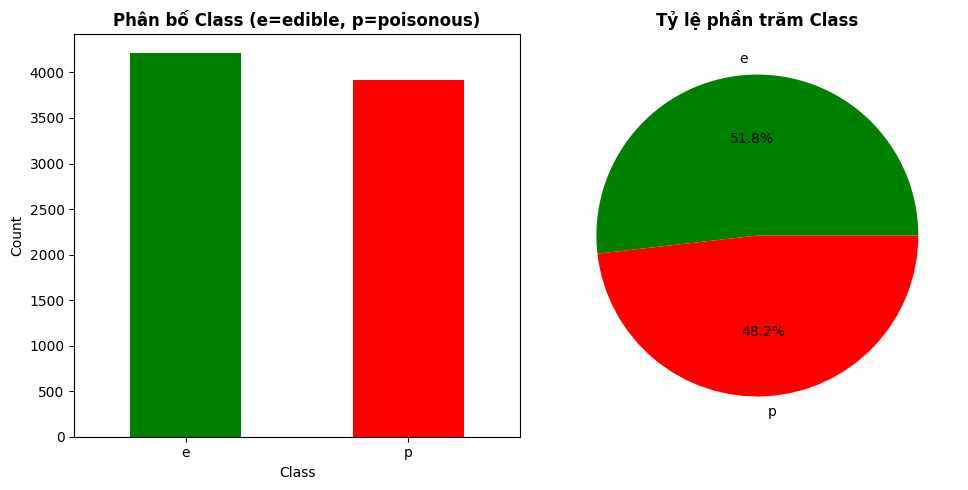

In [6]:
# Phân bố của class
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df["class"].value_counts().plot(kind="bar", color=["green", "red"])
plt.title("Phân bố Class (e=edible, p=poisonous)", fontsize=12, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df["class"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["green", "red"])
plt.title("Tỷ lệ phần trăm Class", fontsize=12, fontweight="bold")
plt.ylabel("")

plt.tight_layout()
plt.show()


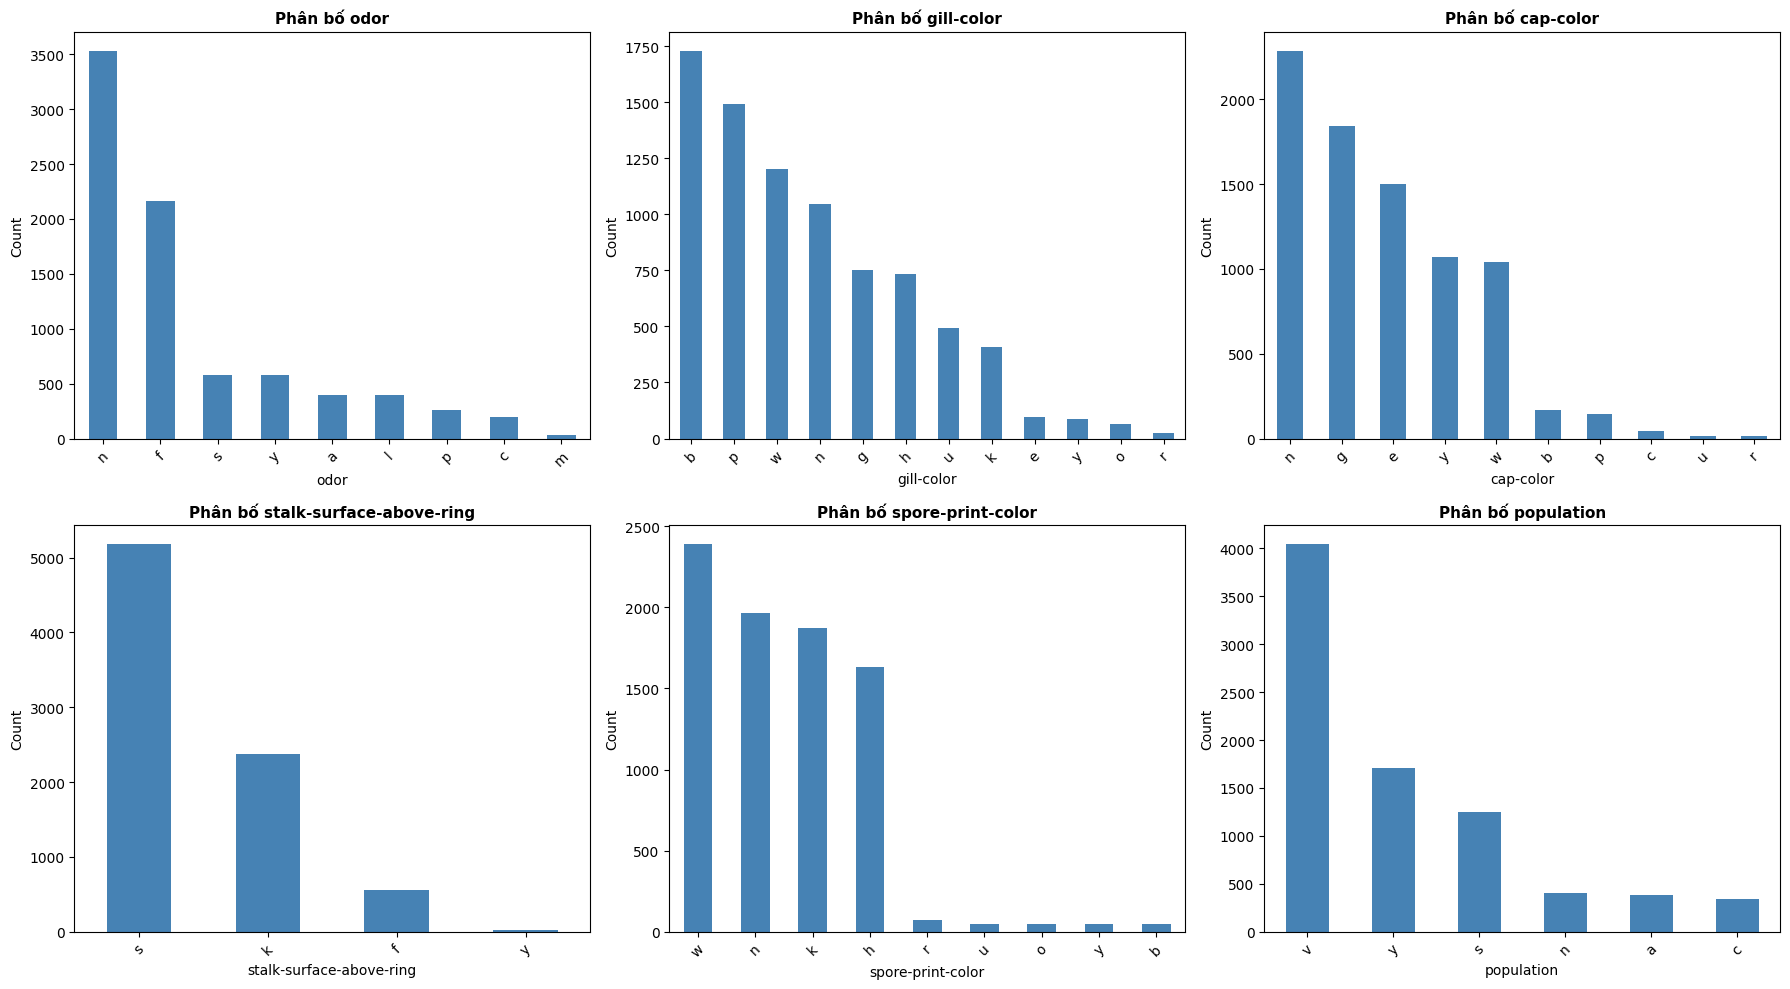

In [7]:
# Phân bố một số features quan trọng
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features_to_plot = [
    "odor",
    "gill-color",
    "cap-color",
    "stalk-surface-above-ring",
    "spore-print-color",
    "population",
]

for idx, feature in enumerate(features_to_plot):
    row = idx // 3
    col = idx % 3

    df[feature].value_counts().plot(kind="bar", ax=axes[row, col], color="steelblue")
    axes[row, col].set_title(f"Phân bố {feature}", fontsize=11, fontweight="bold")
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel("Count")
    axes[row, col].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


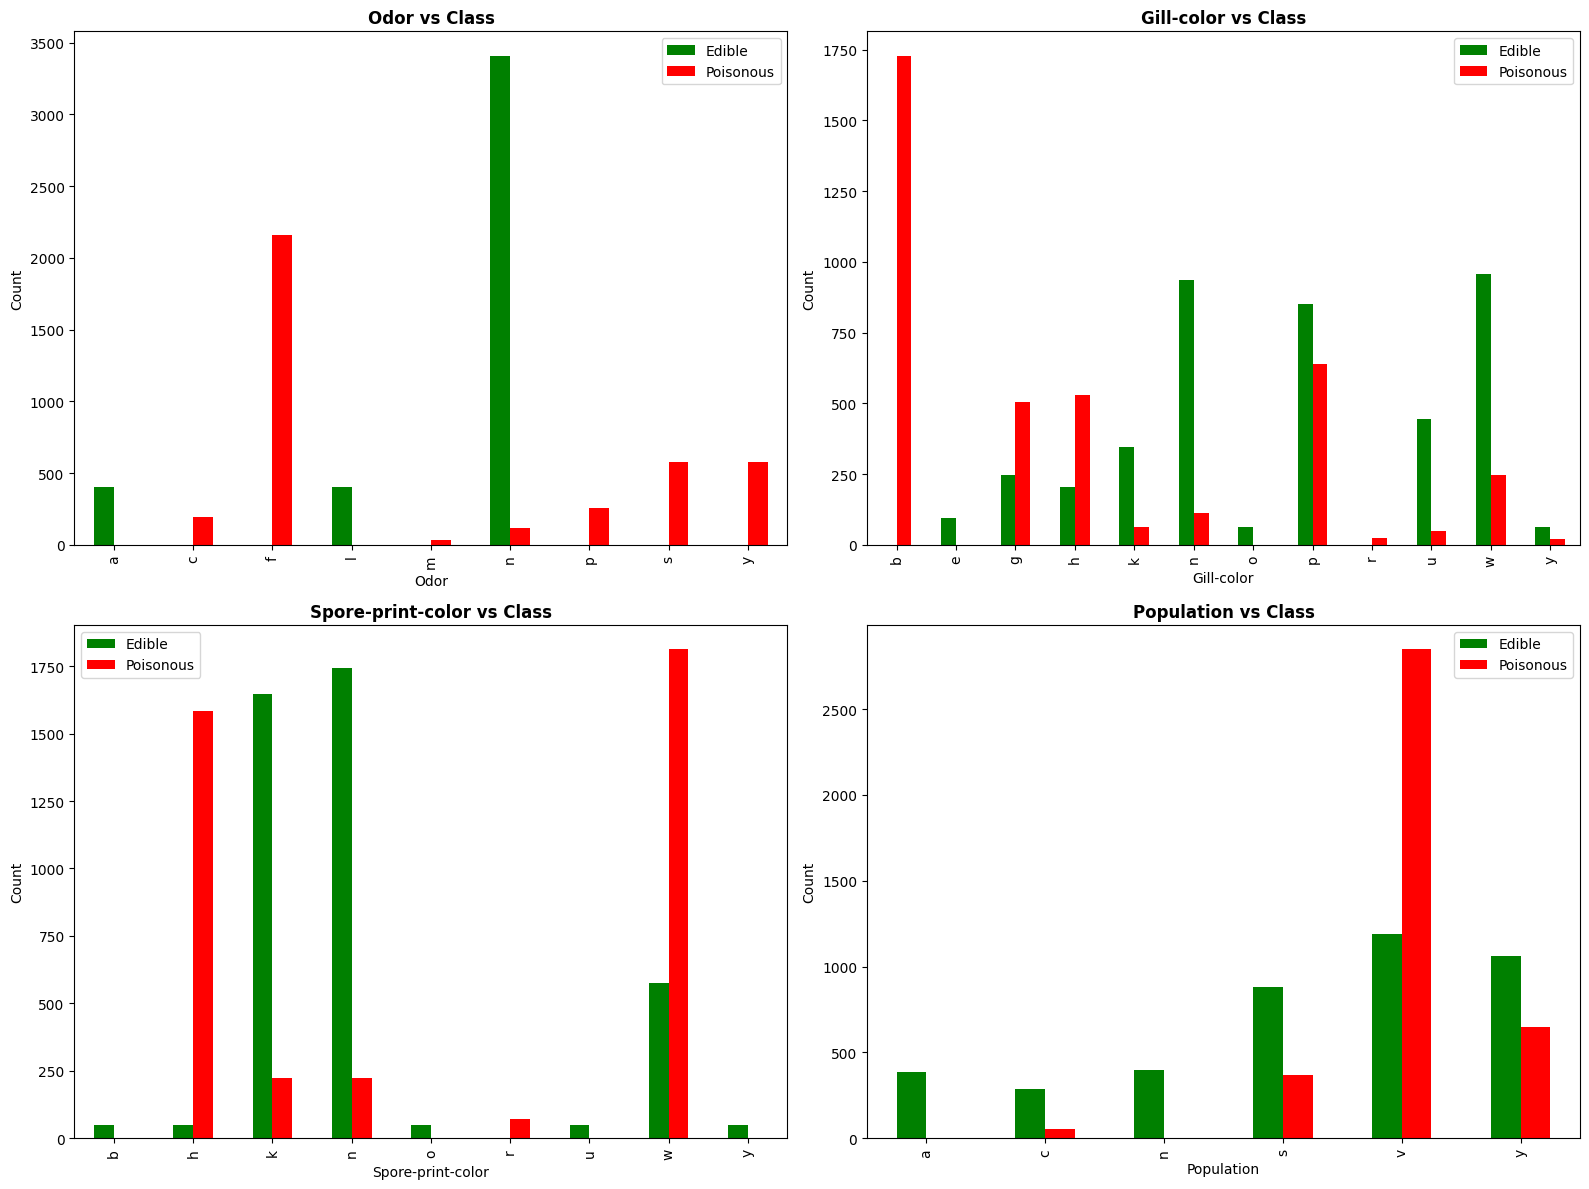

In [8]:
# Phân tích mối quan hệ giữa một số features và class
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Odor vs Class
pd.crosstab(df["odor"], df["class"]).plot(
    kind="bar", ax=axes[0, 0], color=["green", "red"]
)
axes[0, 0].set_title("Odor vs Class", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Odor")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend(["Edible", "Poisonous"])

# Gill-color vs Class
pd.crosstab(df["gill-color"], df["class"]).plot(
    kind="bar", ax=axes[0, 1], color=["green", "red"]
)
axes[0, 1].set_title("Gill-color vs Class", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Gill-color")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend(["Edible", "Poisonous"])

# Spore-print-color vs Class
pd.crosstab(df["spore-print-color"], df["class"]).plot(
    kind="bar", ax=axes[1, 0], color=["green", "red"]
)
axes[1, 0].set_title("Spore-print-color vs Class", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Spore-print-color")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend(["Edible", "Poisonous"])

# Population vs Class
pd.crosstab(df["population"], df["class"]).plot(
    kind="bar", ax=axes[1, 1], color=["green", "red"]
)
axes[1, 1].set_title("Population vs Class", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Population")
axes[1, 1].set_ylabel("Count")
axes[1, 1].legend(["Edible", "Poisonous"])

plt.tight_layout()
plt.show()


## 3. Tiền xử lý dữ liệu


In [9]:
# Tạo bản sao để xử lý
df_processed = df.copy()

# Kiểm tra và xử lý missing values (nếu có)
print("Missing values before processing:")
print(df_processed.isnull().sum().sum())

# Kiểm tra các giá trị '?' trong dữ liệu (thường là missing values trong mushroom dataset)
for col in df_processed.columns:
    if "?" in df_processed[col].values:
        print(f"Column {col} contains '?' values")

print("\nDữ liệu đã sạch, không có missing values!")


Missing values before processing:
0
Column stalk-root contains '?' values

Dữ liệu đã sạch, không có missing values!


In [10]:
# Label Encoding cho tất cả các features
# Vì tất cả dữ liệu đều là categorical, ta cần encode sang số

label_encoders = {}
for column in df_processed.columns:
    le = LabelEncoder()
    df_processed[column] = le.fit_transform(df_processed[column])
    label_encoders[column] = le

print("Dữ liệu sau khi Label Encoding:")
print(df_processed.head(10))
print("\nKiểu dữ liệu:")
print(df_processed.dtypes.unique())
print("\nShape:", df_processed.shape)


Dữ liệu sau khi Label Encoding:
   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      1          5            2          4        1     6                1   
1      0          5            2          9        1     0                1   
2      0          0            2          8        1     3                1   
3      1          5            3          8        1     6                1   
4      0          5            2          3        0     5                1   
5      0          5            3          9        1     0                1   
6      0          0            2          8        1     0                1   
7      0          0            3          8        1     3                1   
8      1          5            3          8        1     6                1   
9      0          0            2          9        1     0                1   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
0             0          

In [11]:
# Lưu mapping của class để dễ hiểu kết quả
class_mapping = {0: "edible", 1: "poisonous"}
print("Class mapping:")
for key, value in class_mapping.items():
    print(f"  {key}: {value}")


Class mapping:
  0: edible
  1: poisonous


In [12]:
# Tách features và target
X = df_processed.drop("class", axis=1)
y = df_processed["class"]

print("Shape của X:", X.shape)
print("Shape của y:", y.shape)
print("\nCác features (", len(X.columns), "features ):")
print(X.columns.tolist())


Shape của X: (8124, 22)
Shape của y: (8124,)

Các features ( 22 features ):
['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [13]:
# Chia dữ liệu thành tập train và test (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Kích thước tập train:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print("\nKích thước tập test:")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print("\nPhân bố của y_train:")
print(y_train.value_counts())
print("\nPhân bố của y_test:")
print(y_test.value_counts())


Kích thước tập train:
X_train: (6499, 22), y_train: (6499,)

Kích thước tập test:
X_test: (1625, 22), y_test: (1625,)

Phân bố của y_train:
class
0    3366
1    3133
Name: count, dtype: int64

Phân bố của y_test:
class
0    842
1    783
Name: count, dtype: int64


## 4. Xây dựng mô hình Naive Bayes

Với dữ liệu categorical đã được encode, ta sẽ sử dụng **MultinomialNB** - phù hợp với dữ liệu đếm và categorical.


In [14]:
# Khởi tạo và huấn luyện mô hình Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print("Mô hình Multinomial Naive Bayes đã được huấn luyện!")
print("Các tham số của mô hình:")
print(f"Classes: {nb_model.classes_}")
print(f"Class prior probabilities: {nb_model.class_log_prior_}")
print(f"Number of features: {nb_model.n_features_in_}")


Mô hình Multinomial Naive Bayes đã được huấn luyện!
Các tham số của mô hình:
Classes: [0 1]
Class prior probabilities: [-0.65792322 -0.72965731]
Number of features: 22


## 5. Dự đoán và đánh giá mô hình


In [15]:
# Dự đoán trên tập train và test
y_train_pred = nb_model.predict(X_train)
y_test_pred = nb_model.predict(X_test)

# Tính accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=== KẾT QUẢ ĐÁNH GIÁ ===")
print(f"\nAccuracy trên tập Train: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Accuracy trên tập Test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nChênh lệch (Overfitting check): {abs(train_accuracy - test_accuracy):.4f}")


=== KẾT QUẢ ĐÁNH GIÁ ===

Accuracy trên tập Train: 0.8074 (80.74%)
Accuracy trên tập Test: 0.8129 (81.29%)

Chênh lệch (Overfitting check): 0.0056


In [16]:
# Classification Report
print("\n=== CLASSIFICATION REPORT (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=["Edible", "Poisonous"]))



=== CLASSIFICATION REPORT (Test Set) ===
              precision    recall  f1-score   support

      Edible       0.76      0.93      0.84       842
   Poisonous       0.90      0.69      0.78       783

    accuracy                           0.81      1625
   macro avg       0.83      0.81      0.81      1625
weighted avg       0.83      0.81      0.81      1625



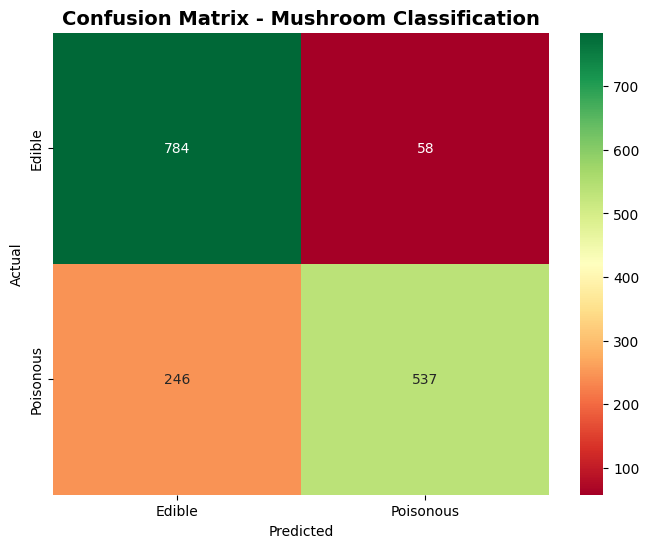


Confusion Matrix:
[[784  58]
 [246 537]]

True Negatives (Edible correctly predicted): 784
False Positives (Edible predicted as Poisonous): 58
False Negatives (Poisonous predicted as Edible): 246 ⚠️ NGUY HIỂM!
True Positives (Poisonous correctly predicted): 537

Tỷ lệ dự đoán đúng: 81.29%
Tỷ lệ dự đoán sai: 18.71%


In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="RdYlGn",
    xticklabels=["Edible", "Poisonous"],
    yticklabels=["Edible", "Poisonous"],
)
plt.title("Confusion Matrix - Mushroom Classification", fontsize=14, fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives (Edible correctly predicted): {cm[0,0]}")
print(f"False Positives (Edible predicted as Poisonous): {cm[0,1]}")
print(f"False Negatives (Poisonous predicted as Edible): {cm[1,0]} ⚠️ NGUY HIỂM!")
print(f"True Positives (Poisonous correctly predicted): {cm[1,1]}")

# Tính tỷ lệ phần trăm
total = cm.sum()
print(f"\nTỷ lệ dự đoán đúng: {(cm[0,0] + cm[1,1])/total*100:.2f}%")
print(f"Tỷ lệ dự đoán sai: {(cm[0,1] + cm[1,0])/total*100:.2f}%")


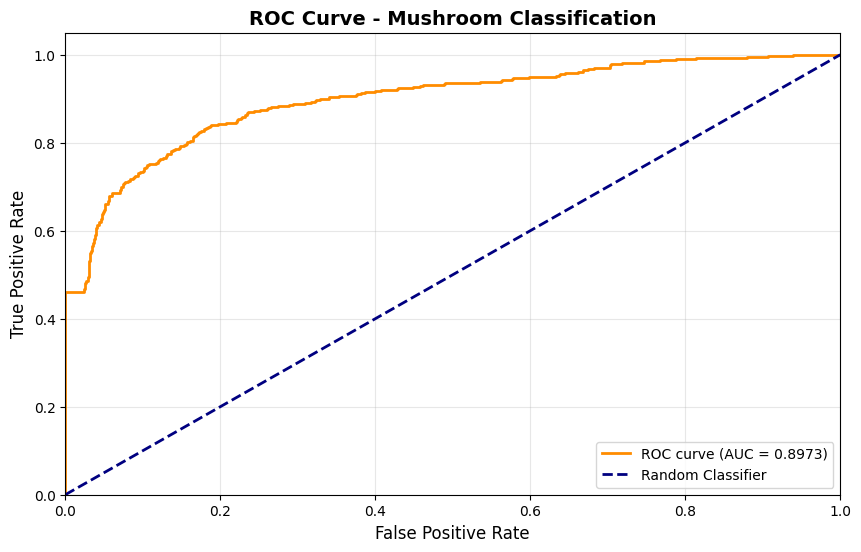


AUC Score: 0.8973


In [18]:
# ROC Curve và AUC Score
y_test_proba = nb_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - Mushroom Classification", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")
if roc_auc > 0.95:
    print("✓ Mô hình có khả năng phân loại XUẤT SẮC!")


## 6. Phân tích các trường hợp dự đoán sai


In [19]:
# Tìm các mẫu bị dự đoán sai
incorrect_predictions = X_test[y_test != y_test_pred]
incorrect_actual = y_test[y_test != y_test_pred]
incorrect_predicted = y_test_pred[y_test != y_test_pred]

print(f"Số lượng dự đoán SAI: {len(incorrect_predictions)} / {len(X_test)}")
print(f"Tỷ lệ dự đoán sai: {len(incorrect_predictions)/len(X_test)*100:.2f}%")

if len(incorrect_predictions) > 0:
    print("\n=== MỘT SỐ MẪU DỰ ĐOÁN SAI ===")
    for i in range(min(5, len(incorrect_predictions))):
        print(f"\nMẫu {i+1}:")
        print(f"  Actual: {class_mapping[incorrect_actual.iloc[i]]}")
        print(f"  Predicted: {class_mapping[incorrect_predicted[i]]}")
        print(f"  Features: {incorrect_predictions.iloc[i].to_dict()}")
else:
    print("\n✓ HOÀN HẢO! Không có mẫu nào bị dự đoán sai!")


Số lượng dự đoán SAI: 304 / 1625
Tỷ lệ dự đoán sai: 18.71%

=== MỘT SỐ MẪU DỰ ĐOÁN SAI ===

Mẫu 1:
  Actual: poisonous
  Predicted: edible
  Features: {'cap-shape': 5, 'cap-surface': 3, 'cap-color': 3, 'bruises': 0, 'odor': 2, 'gill-attachment': 1, 'gill-spacing': 0, 'gill-size': 0, 'gill-color': 7, 'stalk-shape': 0, 'stalk-root': 1, 'stalk-surface-above-ring': 1, 'stalk-surface-below-ring': 1, 'stalk-color-above-ring': 6, 'stalk-color-below-ring': 4, 'veil-type': 0, 'veil-color': 2, 'ring-number': 1, 'ring-type': 2, 'spore-print-color': 1, 'population': 5, 'habitat': 0}

Mẫu 2:
  Actual: poisonous
  Predicted: edible
  Features: {'cap-shape': 5, 'cap-surface': 2, 'cap-color': 8, 'bruises': 0, 'odor': 1, 'gill-attachment': 1, 'gill-spacing': 0, 'gill-size': 1, 'gill-color': 9, 'stalk-shape': 0, 'stalk-root': 1, 'stalk-surface-above-ring': 2, 'stalk-surface-below-ring': 2, 'stalk-color-above-ring': 7, 'stalk-color-below-ring': 7, 'veil-type': 0, 'veil-color': 2, 'ring-number': 1, 'ring-

## 7. Dự đoán với dữ liệu mới


In [20]:
# Lấy một số mẫu từ tập test để demo
sample_indices = [0, 10, 50, 100, 200]
sample_data = X_test.iloc[sample_indices]
sample_actual = y_test.iloc[sample_indices]

# Dự đoán
predictions = nb_model.predict(sample_data)
probabilities = nb_model.predict_proba(sample_data)

print("=== DỰ ĐOÁN MẪU MỚI ===\n")
for i in range(len(sample_indices)):
    actual_class = class_mapping[sample_actual.iloc[i]]
    predicted_class = class_mapping[predictions[i]]
    prob_edible = probabilities[i][0] * 100
    prob_poisonous = probabilities[i][1] * 100

    print(f"Mẫu {i+1}:")
    print(f"  Actual: {actual_class}")
    print(f"  Predicted: {predicted_class}")
    print(f"  Xác suất Edible: {prob_edible:.2f}%")
    print(f"  Xác suất Poisonous: {prob_poisonous:.2f}%")

    if actual_class == predicted_class:
        print(f"  ✓ Dự đoán ĐÚNG!")
    else:
        print(f"  ✗ Dự đoán SAI!")
    print()


=== DỰ ĐOÁN MẪU MỚI ===

Mẫu 1:
  Actual: poisonous
  Predicted: edible
  Xác suất Edible: 90.31%
  Xác suất Poisonous: 9.69%
  ✗ Dự đoán SAI!

Mẫu 2:
  Actual: poisonous
  Predicted: poisonous
  Xác suất Edible: 2.29%
  Xác suất Poisonous: 97.71%
  ✓ Dự đoán ĐÚNG!

Mẫu 3:
  Actual: edible
  Predicted: edible
  Xác suất Edible: 93.42%
  Xác suất Poisonous: 6.58%
  ✓ Dự đoán ĐÚNG!

Mẫu 4:
  Actual: poisonous
  Predicted: poisonous
  Xác suất Edible: 19.49%
  Xác suất Poisonous: 80.51%
  ✓ Dự đoán ĐÚNG!

Mẫu 5:
  Actual: poisonous
  Predicted: poisonous
  Xác suất Edible: 0.00%
  Xác suất Poisonous: 100.00%
  ✓ Dự đoán ĐÚNG!



## 8. Feature Importance Analysis


=== TOP 10 FEATURES QUAN TRỌNG NHẤT ===

              Feature  Importance
7           gill-size    2.218142
6        gill-spacing    2.194421
3             bruises    1.292282
8          gill-color    0.711673
10         stalk-root    0.655781
21            habitat    0.604350
18          ring-type    0.552920
1         cap-surface    0.350992
19  spore-print-color    0.338578
20         population    0.326368


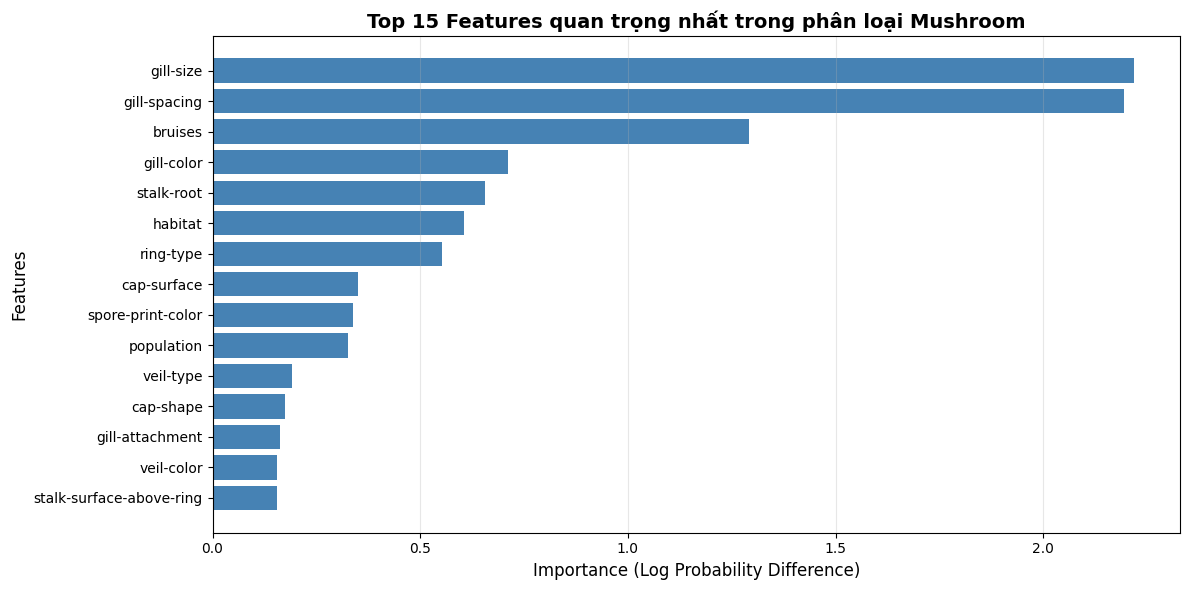

In [21]:
# Phân tích feature log probabilities
# Features có sự khác biệt lớn giữa 2 class là quan trọng

feature_log_prob_diff = np.abs(
    nb_model.feature_log_prob_[0] - nb_model.feature_log_prob_[1]
)
feature_importance_df = pd.DataFrame(
    {"Feature": X.columns, "Importance": feature_log_prob_diff}
).sort_values("Importance", ascending=False)

print("=== TOP 10 FEATURES QUAN TRỌNG NHẤT ===\n")
print(feature_importance_df.head(10))

# Visualize
plt.figure(figsize=(12, 6))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features["Importance"], color="steelblue")
plt.yticks(range(len(top_features)), top_features["Feature"])
plt.xlabel("Importance (Log Probability Difference)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title(
    "Top 15 Features quan trọng nhất trong phân loại Mushroom",
    fontsize=14,
    fontweight="bold",
)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 9. So sánh hiệu suất với các ngưỡng khác nhau


=== KẾT QUẢ VỚI CÁC NGƯỠNG KHÁC NHAU ===

   Threshold  Accuracy  False Negatives  True Negatives  False Positives  \
0        0.3  0.820308              193             743               99   
1        0.5  0.812923              246             784               58   
2        0.7  0.793231              299             805               37   
3        0.9  0.750769              379             816               26   

   True Positives  
0             590  
1             537  
2             484  
3             404  

⚠️ False Negatives (nấm độc dự đoán là ăn được) là nguy hiểm nhất!


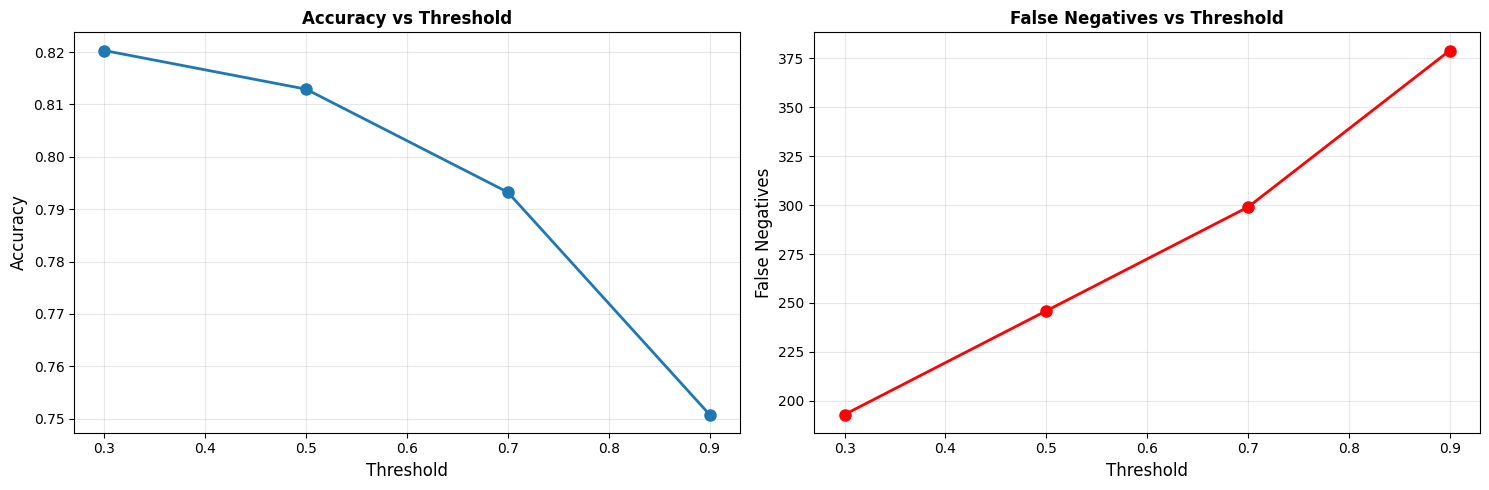

In [22]:
# Thử các ngưỡng khác nhau cho classification
thresholds_to_test = [0.3, 0.5, 0.7, 0.9]
y_test_proba_poisonous = nb_model.predict_proba(X_test)[:, 1]

results = []
for threshold in thresholds_to_test:
    y_pred_threshold = (y_test_proba_poisonous >= threshold).astype(int)
    accuracy = accuracy_score(y_test, y_pred_threshold)
    cm = confusion_matrix(y_test, y_pred_threshold)

    # False negatives là quan trọng nhất (nấm độc bị phân loại là ăn được)
    false_negatives = cm[1, 0] if cm.shape == (2, 2) else 0

    results.append(
        {
            "Threshold": threshold,
            "Accuracy": accuracy,
            "False Negatives": false_negatives,
            "True Negatives": cm[0, 0] if cm.shape == (2, 2) else 0,
            "False Positives": cm[0, 1] if cm.shape == (2, 2) else 0,
            "True Positives": cm[1, 1] if cm.shape == (2, 2) else 0,
        }
    )

results_df = pd.DataFrame(results)
print("=== KẾT QUẢ VỚI CÁC NGƯỠNG KHÁC NHAU ===\n")
print(results_df)
print("\n⚠️ False Negatives (nấm độc dự đoán là ăn được) là nguy hiểm nhất!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    results_df["Threshold"],
    results_df["Accuracy"],
    marker="o",
    linewidth=2,
    markersize=8,
)
axes[0].set_xlabel("Threshold", fontsize=12)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Accuracy vs Threshold", fontsize=12, fontweight="bold")
axes[0].grid(alpha=0.3)

axes[1].plot(
    results_df["Threshold"],
    results_df["False Negatives"],
    marker="o",
    color="red",
    linewidth=2,
    markersize=8,
)
axes[1].set_xlabel("Threshold", fontsize=12)
axes[1].set_ylabel("False Negatives", fontsize=12)
axes[1].set_title("False Negatives vs Threshold", fontsize=12, fontweight="bold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Tổng kết Pipeline


In [23]:
print("=" * 70)
print("TỔNG KẾT PIPELINE MACHINE LEARNING - MUSHROOM CLASSIFICATION")
print("=" * 70)
print(f"\n1. Dataset: mushrooms.csv")
print(f"   - Số mẫu: {len(df)}")
print(f"   - Số features: {X.shape[1]} features (tất cả categorical)")
print(f"   - Biến target: class (Binary: edible/poisonous)")
print(
    f"   - Phân bố class: Edible={len(df[df['class']=='e'])}, Poisonous={len(df[df['class']=='p'])}"
)

print(f"\n2. Data Split:")
print(f"   - Training set: {len(X_train)} mẫu ({len(X_train)/len(df)*100:.1f}%)")
print(f"   - Test set: {len(X_test)} mẫu ({len(X_test)/len(df)*100:.1f}%)")

print(f"\n3. Preprocessing:")
print(
    f"   - Encoding: Label Encoding cho tất cả {len(df.columns)} features categorical"
)
print(f"   - No scaling needed (categorical data)")

print(f"\n4. Model: Multinomial Naive Bayes")
print(f"   - Algorithm: MultinomialNB")
print(f"   - Lý do: Phù hợp với dữ liệu categorical đã encode")

print(f"\n5. Performance:")
print(f"   - Train Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   - AUC Score: {roc_auc:.4f}")
print(f"   - False Negatives: {cm[1,0]} (nấm độc dự đoán là ăn được)")
print(f"   - False Positives: {cm[0,1]} (nấm ăn được dự đoán là độc)")

print(f"\n6. Top 5 Features quan trọng nhất:")
for i, row in feature_importance_df.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.4f}")

print(f"\n7. Kết luận:")
if test_accuracy >= 0.95:
    print(f"   ✓ Mô hình hoạt động XUẤT SẮC với accuracy {test_accuracy*100:.2f}%")
elif test_accuracy >= 0.90:
    print(f"   ✓ Mô hình hoạt động RẤT TỐT với accuracy {test_accuracy*100:.2f}%")
elif test_accuracy >= 0.85:
    print(f"   ✓ Mô hình hoạt động TỐT với accuracy {test_accuracy*100:.2f}%")
else:
    print(f"   ⚠ Mô hình cần cải thiện (accuracy {test_accuracy*100:.2f}%)")

if cm[1, 0] == 0:
    print(f"   ✓ HOÀN HẢO! Không có False Negatives (an toàn 100%)")
else:
    print(f"   ⚠ Cần lưu ý: Có {cm[1,0]} trường hợp nấm độc bị phân loại sai!")

print("\n" + "=" * 70)
print("\n🍄 Lưu ý: Trong phân loại nấm, False Negative (nấm độc nhầm thành")
print("   ăn được) nguy hiểm hơn False Positive (nấm ăn được nhầm thành độc)!")
print("=" * 70)


TỔNG KẾT PIPELINE MACHINE LEARNING - MUSHROOM CLASSIFICATION

1. Dataset: mushrooms.csv
   - Số mẫu: 8124
   - Số features: 22 features (tất cả categorical)
   - Biến target: class (Binary: edible/poisonous)
   - Phân bố class: Edible=4208, Poisonous=3916

2. Data Split:
   - Training set: 6499 mẫu (80.0%)
   - Test set: 1625 mẫu (20.0%)

3. Preprocessing:
   - Encoding: Label Encoding cho tất cả 23 features categorical
   - No scaling needed (categorical data)

4. Model: Multinomial Naive Bayes
   - Algorithm: MultinomialNB
   - Lý do: Phù hợp với dữ liệu categorical đã encode

5. Performance:
   - Train Accuracy: 0.8074 (80.74%)
   - Test Accuracy: 0.8129 (81.29%)
   - AUC Score: 0.8973
   - False Negatives: 379 (nấm độc dự đoán là ăn được)
   - False Positives: 26 (nấm ăn được dự đoán là độc)

6. Top 5 Features quan trọng nhất:
   8. gill-size: 2.2181
   7. gill-spacing: 2.1944
   4. bruises: 1.2923
   9. gill-color: 0.7117
   11. stalk-root: 0.6558

7. Kết luận:
   ⚠ Mô hình cần cả